# pmax_sanstivity 

## imports

In [1]:
## imports 

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from sklearn.decomposition import PCA
from itertools import combinations
from pathlib import Path
import os

FIGURE_3_DIR = Path(os.environ["PUBLICATION_OUTPUT_ROOT"]).expanduser().resolve() / "Figure_3_Composition"

PMAX_ALL_PDF = FIGURE_3_DIR / "pmax_specialist_curves_simulations_and_real.pdf"
PMAX_TISSUE_PDF = FIGURE_3_DIR / "pmax_specialist_curves_by_tissue_with_simulations.pdf"

TARGET_TISSUE_ORDER = [
    "Bladder",
    "Fat",
    "Heart",
    "Kidney",
    "Large Intestine",
    "Liver",
    "Lung",
    "Pancreas",
    "Skin",
    "Small Intestine",
    "Spleen",
    "Thymus",
    "Tongue",
    "Trachea",
]
TISSUE_PALETTE = {
    "Bladder": "#3953A4",
    "Fat": "#ED2024",
    "Heart": "#6ABD45",
    "Kidney": "#0F1031",

    "Large Intestine": "#E03F97",
    "Large_intestine": "#E03F97",

    "Liver": "#1F5429",
    "Lung": "#FED304",
    "Pancreas": "#4996D2",
    "Skin": "#9A4D42",

    "Small Intestine": "#DF7D26",
    "Small_intestine": "#DF7D26",

    "Spleen": "#714EA0",
    "Thymus": "#1E9698",
    "Tongue": "#E3AFD1",
    "Trachea": "#A93493",

    # aliases for the exact names appearing in your plot
    "Marrow": "#A781BA",
    "Bone marrow": "#A781BA",
    "Bone_Marrow": "#A781BA",

    "Limb Muscle": "#18BDC2",
    "Limb muscle": "#18BDC2",

    "Mammary Gland": "#C29A2D",
    "Mammary gland": "#C29A2D",
    "Mammary": "#C29A2D",

    "Stomach": "#C49A6C",
    "Muscle": "#5C8A00",
}

ARCHETYPE_PALETTE = {
    1: "#FFFF33",
    2: "#377EB8",
    3: "#4DAF4A",
    4: "#E41A1C",
    5: "#984EA3",
    6: "#FF7F00",
    0: "#808080",
}


## functions 

In [3]:
def make_archetypes(n_arch=5, n_genes=8000, marker_boost=4, seed=42):
    """
    Create archetype gene-expression profiles.
    Each row is one archetype and sums to 1.
    """
    rng = np.random.default_rng(seed)

    arch = rng.gamma(
        shape=1.5,
        scale=1.0,
        size=(n_arch, n_genes)
    )

    genes_per_arch = n_genes // n_arch

    for a in range(n_arch):
        start = a * genes_per_arch
        end = (a + 1) * genes_per_arch
        arch[a, start:end] *= marker_boost

    arch = arch / arch.sum(axis=1, keepdims=True)

    return arch

def simulate_cells(arch, n_cells=15000, alpha=0.3, lib_size=8000, seed=1):
    """
    Simulate cells as mixtures of archetypes.

    Small alpha -> specialist-like / near vertices.
    Large alpha -> generalist-like / near center.
    """
    rng = np.random.default_rng(seed)

    n_arch, n_genes = arch.shape

    weights = rng.dirichlet(
        alpha=np.repeat(alpha, n_arch),
        size=n_cells
    )

    probs = weights @ arch

    counts = rng.poisson(probs * lib_size)

    expr = counts / counts.sum(axis=1, keepdims=True) * 1e4
    expr = np.log1p(expr)

    return expr, weights

def plot_pca_3d(cells_pca, arch_pca, weights, title, pca):
    """
    Plot cells and archetypes in 3D PCA space.
    Cells are colored by PMAX.
    Archetypes are connected by edges.
    Axes are hidden.
    """
    n_arch = weights.shape[1]
    pmax = weights.max(axis=1)
    evr = pca.explained_variance_ratio_ * 100

    fig = go.Figure()

    # Cells
    fig.add_trace(
        go.Scatter3d(
            x=cells_pca[:, 0],
            y=cells_pca[:, 1],
            z=cells_pca[:, 2],
            mode="markers",
            name="Cells",
            showlegend=False,
            marker=dict(
                size=2,
                opacity=0.25,
                color=pmax,
                cmin=1 / n_arch,
                cmax=1.0,
                colorbar=dict(
                    title="PMAX",
                    thickness=22,
                    len=0.7,
                    x=1.03
                )
            )
        )
    )

    # Edges between archetypes
    for i, j in combinations(range(n_arch), 2):
        fig.add_trace(
            go.Scatter3d(
                x=[arch_pca[i, 0], arch_pca[j, 0]],
                y=[arch_pca[i, 1], arch_pca[j, 1]],
                z=[arch_pca[i, 2], arch_pca[j, 2]],
                mode="lines",
                showlegend=False,
                hoverinfo="skip",
                line=dict(
                    width=5,
                    color="black"
                )
            )
        )

    # Archetype vertices
    fig.add_trace(
        go.Scatter3d(
            x=arch_pca[:, 0],
            y=arch_pca[:, 1],
            z=arch_pca[:, 2],
            mode="markers+text",
            name="Archetypes",
            showlegend=False,
            text=[f"A{i+1}" for i in range(n_arch)],
            textposition="top center",
            marker=dict(
                size=11,
                symbol="diamond",
                opacity=1.0
            )
        )
    )

    fig.update_layout(
        title=f"{title}<br><sup>PC1={evr[0]:.1f}%, PC2={evr[1]:.1f}%, PC3={evr[2]:.1f}%</sup>",
        width=900,
        height=750,
        margin=dict(l=10, r=120, b=10, t=70),
        scene=dict(
            xaxis=dict(visible=False),
            yaxis=dict(visible=False),
            zaxis=dict(visible=False),
            aspectmode="data"
        )
    )

    fig.show()
def plot_pmax_curve(weights_by_name, scenarios, n_arch):
    """
    Plot percent of specialist cells as a function of PMAX threshold.

    Specialist at threshold t = cell with PMAX >= t.
    """
    thresholds = np.linspace(1 / n_arch, 1.0, 250)

    plt.figure(figsize=(7, 5))

    for name, alpha in scenarios:
        pmax = weights_by_name[name].max(axis=1)

        percent_specialists = [
            (pmax >= t).mean() * 100
            for t in thresholds
        ]

        plt.plot(
            thresholds,
            percent_specialists,
            linewidth=2.5,
            label=name
        )

    plt.axvline(0.3, linestyle="--", linewidth=1)
    plt.axvline(0.5, linestyle="--", linewidth=1)

    plt.xlabel("PMAX threshold")
    plt.ylabel("Specialist cells (%)")
    plt.title("Specialist fraction across PMAX thresholds")
    plt.xlim(1 / n_arch, 1.0)
    plt.ylim(0, 105)
    plt.legend(frameon=False)
    plt.tight_layout()
    plt.show()

In [4]:
def get_archetype_columns(df):
    """
    Return archetype weight columns.
    """
    return [col for col in df.columns if col.startswith("Archetype_")]


def get_pmax_from_real_df(df):
    """
    Calculate PMAX from real archetype weight table.
    """
    arch_cols = get_archetype_columns(df)
    return df[arch_cols].max(axis=1).to_numpy()


def specialist_curve_from_pmax(pmax, thresholds):
    """
    Percent of cells with PMAX >= threshold.
    """
    return np.array([
        (pmax >= t).mean() * 100
        for t in thresholds
    ])


def specialist_curve_from_weights(weights, thresholds):
    """
    Same calculation, but directly from simulated weights matrix.
    """
    pmax = weights.max(axis=1)
    return specialist_curve_from_pmax(pmax, thresholds)


In [5]:

def short_scenario_label(name):
    """
    Remove alpha details from scenario labels.
    """
    return name.split(",")[0]


def get_archetype_columns(df):
    """
    Detect archetype weight columns.
    """
    return [col for col in df.columns if col.startswith("Archetype_")]


def get_pmax_from_real_df(df):
    """
    PMAX = maximum archetype weight per cell.
    """
    arch_cols = get_archetype_columns(df)

    if len(arch_cols) == 0:
        raise ValueError("No archetype columns found. Expected columns like Archetype_1, Archetype_2, ...")

    return df[arch_cols].max(axis=1).to_numpy()


def pmax_curve(pmax, thresholds):
    """
    Percent of cells with PMAX >= threshold.
    """
    return np.array([
        (pmax >= t).mean() * 100
        for t in thresholds
    ])


def simulate_pmax_for_scenario(alpha, n_arch, n_cells=15000, seed=1):
    """
    Simulate PMAX directly from Dirichlet weights.
    No expression simulation is needed for PMAX curves.
    """
    rng = np.random.default_rng(seed)

    weights = rng.dirichlet(
        alpha=np.repeat(alpha, n_arch),
        size=n_cells
    )

    return weights.max(axis=1)
    

In [6]:
def plot_pmax_curves_by_tissue(
    scenarios,
    real_weights_by_cell_type,
    tissue_col="Tissue",
    sim_n_arch_by_cell_type=None,
    output_pdf=None,
    sim_n_cells=15000,
    font_size=13,
    line_width=2.7,
):
    """
    Plot PMAX specialist curves by tissue.
    Each panel is one cell type.
    Each cell type can use a different number of simulated archetypes.
    """

    thresholds = np.linspace(0.15, 1.0, 300)

    if sim_n_arch_by_cell_type is None:
        sim_n_arch_by_cell_type = {
            cell_type: 5
            for cell_type in real_weights_by_cell_type.keys()
        }

    plt.rcParams.update({
        "font.size": font_size,
        "axes.titlesize": font_size + 2,
        "axes.labelsize": font_size,
        "xtick.labelsize": font_size - 1,
        "ytick.labelsize": font_size - 1,
        "legend.fontsize": font_size - 2,
    })

    n_cell_types = len(real_weights_by_cell_type)

    fig, axes = plt.subplots(
        1,
        n_cell_types,
        figsize=(6.2 * n_cell_types, 5.6),
        sharex=True,
        sharey=True
    )

    if n_cell_types == 1:
        axes = [axes]

    for ax, (cell_type, df) in zip(axes, real_weights_by_cell_type.items()):

        n_arch_sim = sim_n_arch_by_cell_type.get(cell_type, 5)

        # Simulations as reference for this specific cell type
        for i, (name, alpha) in enumerate(scenarios):
            pmax = simulate_pmax_for_scenario(
                alpha=alpha,
                n_arch=n_arch_sim,
                n_cells=sim_n_cells,
                seed=1000 + i + n_arch_sim
            )

            ax.plot(
                thresholds,
                pmax_curve(pmax, thresholds),
                linestyle="--",
                linewidth=line_width,
                alpha=0.85,
                label=f"simulation: {short_scenario_label(name)}"
            )

        # Real tissue-specific curves
        for tissue, tissue_df in sorted(
            df.groupby(tissue_col),
            key=lambda x: tissue_sort_key(x[0])
        ):
            pmax = get_pmax_from_real_df(tissue_df)

            ax.plot(
                thresholds,
                pmax_curve(pmax, thresholds),
                linewidth=line_width,
                color=tissue_color(tissue),
                label=canonical_tissue(tissue)
            )

        ax.set_title(f"{cell_type}\nSimulated with {n_arch_sim} archetypes")
        ax.set_xlabel("PMAX threshold")
        ax.set_xlim(0.15, 1.0)
        ax.set_ylim(0, 105)

    axes[0].set_ylabel("Specialist cells (%)")

    handles, labels = axes[-1].get_legend_handles_labels()

    fig.legend(
        handles,
        labels,
        frameon=False,
        loc="center left",
        bbox_to_anchor=(1.01, 0.5),
        fontsize=font_size - 2,
    )

    fig.suptitle(
        "Specialist fraction by tissue across PMAX thresholds",
        fontsize=font_size + 3,
        y=1.02
    )

    fig.tight_layout()

    if output_pdf is not None:
        fig.savefig(output_pdf, format="pdf", bbox_inches="tight", facecolor="white")

    plt.show()

In [7]:
def plot_simulations_and_real_pmax_curves(
    scenarios,
    real_weights_by_cell_type,
    output_pdf=None,
    sim_n_arch=5,
    sim_n_cells=15000,
    font_size=13,
    line_width=3.0,
):
    """
    Plot PMAX specialist curves for:
    - simulated alpha scenarios
    - real cell-type archetype weights
    """

    thresholds = np.linspace(0.15, 1.0, 300)

    plt.rcParams.update({
        "font.size": font_size,
        "axes.titlesize": font_size + 2,
        "axes.labelsize": font_size,
        "xtick.labelsize": font_size - 1,
        "ytick.labelsize": font_size - 1,
        "legend.fontsize": font_size - 1,
    })

    fig, ax = plt.subplots(figsize=(9.5, 6))

    # Simulations
    for i, (name, alpha) in enumerate(scenarios):
        pmax = simulate_pmax_for_scenario(
            alpha=alpha,
            n_arch=sim_n_arch,
            n_cells=sim_n_cells,
            seed=i + 1
        )

        ax.plot(
            thresholds,
            pmax_curve(pmax, thresholds),
            linewidth=line_width,
            linestyle="--",
            label=f"simulation: {short_scenario_label(name)}"
        )

    # Real cell types
    for cell_type, df in real_weights_by_cell_type.items():
        pmax = get_pmax_from_real_df(df)

        ax.plot(
            thresholds,
            pmax_curve(pmax, thresholds),
            linewidth=line_width + 0.5,
            label=cell_type
        )

    ax.set_xlabel("PMAX threshold")
    ax.set_ylabel("Specialist cells (%)")
    ax.set_title("Specialist fraction across PMAX thresholds")
    ax.set_xlim(0.15, 1.0)
    ax.set_ylim(0, 105)

    ax.legend(
        frameon=False,
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        borderaxespad=0,
    )

    fig.tight_layout()

    if output_pdf is not None:
        fig.savefig(output_pdf, format="pdf", bbox_inches="tight", facecolor="white")

    plt.show()



In [8]:
TISSUE_NAME_MAP = {
    "Small_intestine": "Small Intestine",
    "Small_Intestine": "Small Intestine",
    "Large_intestine": "Large Intestine",
    "Large_Intestine": "Large Intestine",
    "Bone marrow": "Marrow",
    "Bone_Marrow": "Marrow",
    "Limb muscle": "Limb Muscle",
    "Mammary gland": "Mammary Gland",
    "Mammary": "Mammary Gland",
}


def canonical_tissue(tissue):
    tissue = str(tissue)
    return TISSUE_NAME_MAP.get(tissue, tissue)


def tissue_color(tissue):
    return TISSUE_PALETTE.get(canonical_tissue(tissue), "#BBBBBB")


def tissue_sort_key(tissue):
    tissue = canonical_tissue(tissue)
    if tissue in TARGET_TISSUE_ORDER:
        return TARGET_TISSUE_ORDER.index(tissue)
    return len(TARGET_TISSUE_ORDER)

In [9]:
# -----------------------------
# Parameters
# -----------------------------

n_arch = 5
n_genes = 8000
n_cells = 15000

scenarios = [
    ("specialist-like, alpha=0.03", 0.03),
    ("reality-like, alpha=0.3", 0.3),
    ("generalist-like, alpha=20", 20),
]

arch = make_archetypes(
    n_arch=n_arch,
    n_genes=n_genes,
    marker_boost=4,
    seed=42
)



In [10]:
# -----------------------------
# Simulate cells for each scenario
# -----------------------------

expr_by_name = {}
weights_by_name = {}

for i, (name, alpha) in enumerate(scenarios):
    expr, weights = simulate_cells(
        arch=arch,
        n_cells=n_cells,
        alpha=alpha,
        seed=i + 1
    )

    expr_by_name[name] = expr
    weights_by_name[name] = weights

In [11]:


arch_expr = np.log1p(arch * 1e4)

X_all = np.vstack([
    *expr_by_name.values(),
    arch_expr
])

pca = PCA(n_components=3, random_state=42)
X_pca = pca.fit_transform(X_all)

arch_pca = X_pca[-n_arch:]

# -----------------------------
# Plot 3D PCA for each scenario
# -----------------------------

start = 0

for name, alpha in scenarios:
    end = start + n_cells

    cells_pca = X_pca[start:end]

    plot_pca_3d(
        cells_pca=cells_pca,
        arch_pca=arch_pca,
        weights=weights_by_name[name],
        title=name,
        pca=pca
    )

    start = end

In [12]:

# Paths


FIGURE_3_DIR = Path(os.environ["PUBLICATION_OUTPUT_ROOT"]).expanduser().resolve() / "Figure_3_Composition"

ENDOTHELIAL_WEIGHTS_PATH = FIGURE_3_DIR / "endothelial_archetype_weights.csv"
FIBROBLAST_WEIGHTS_PATH = FIGURE_3_DIR / "fibroblast_archetype_weights.csv"
MACROPHAGE_WEIGHTS_PATH = FIGURE_3_DIR / "macrophage_archetype_weights.csv"


# -----------------------------
# Load real archetype weights
# -----------------------------

endothelial_weights_df = pd.read_csv(ENDOTHELIAL_WEIGHTS_PATH)
fibroblast_weights_df = pd.read_csv(FIBROBLAST_WEIGHTS_PATH)
macrophage_weights_df = pd.read_csv(MACROPHAGE_WEIGHTS_PATH)


real_weights_by_cell_type = {
    "Fibroblasts": fibroblast_weights_df,
    "Macrophages": macrophage_weights_df,
    "Endothelial": endothelial_weights_df,
}


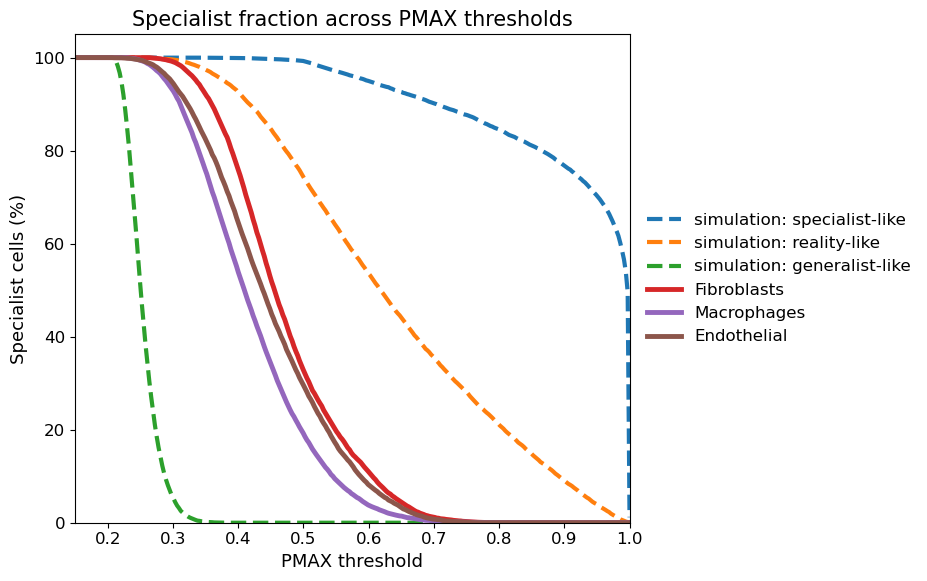

In [13]:
plot_simulations_and_real_pmax_curves(
    scenarios=scenarios,
    real_weights_by_cell_type=real_weights_by_cell_type,
    output_pdf=PMAX_ALL_PDF,
    sim_n_arch=5,
    sim_n_cells=n_cells,
)

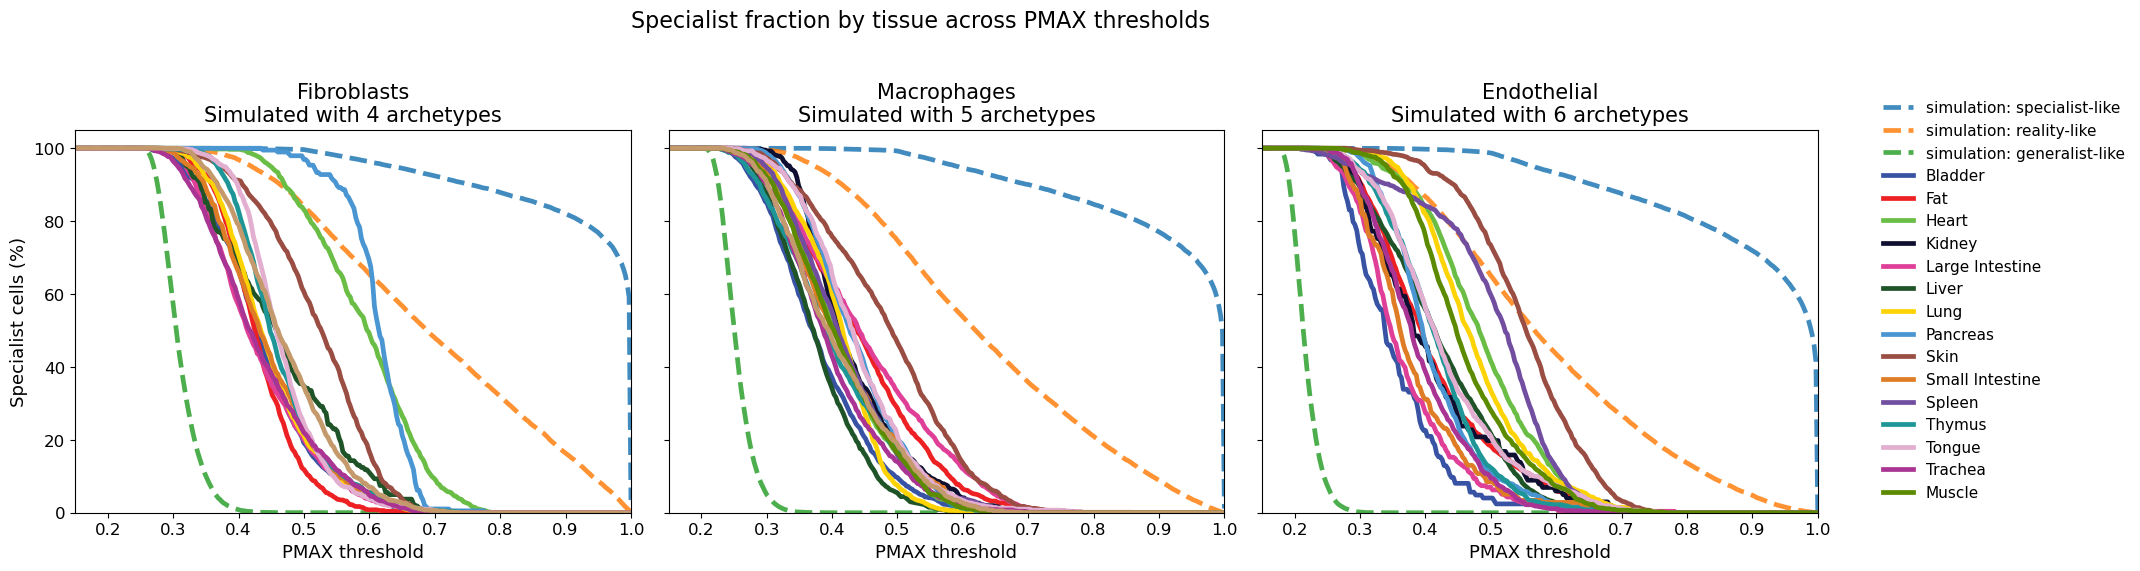

In [14]:
sim_n_arch_by_cell_type = {
    "Fibroblasts": 4,
    "Macrophages": 5,
    "Endothelial": 6,
}

plot_pmax_curves_by_tissue(
    scenarios=scenarios,
    real_weights_by_cell_type=real_weights_by_cell_type,
    tissue_col="Tissue",
    sim_n_arch_by_cell_type=sim_n_arch_by_cell_type,
    output_pdf=PMAX_TISSUE_PDF,
    sim_n_cells=n_cells,
    line_width=3.4,
)